In [1]:
# CELL 1: Setup
import sys
sys.path.append('..')

import os
import torch
import numpy as np
import random
import matplotlib.pyplot as plt

from configs.config import Config
from data.splits import get_patient_splits
from models.bu_net import BUNet
from models.prototypical_segmentation import PrototypicalSegmentation
from models.maml_segmentation import MAMLSegmentation
from data.few_shot_sampler import FewShotSampler
from data.augmented_finetune import (
    kshot_augmented_finetune_eval,
    kshot_augmented_prototypical_eval,
    kshot_augmented_maml_eval,
)
from configs.results_utils import save_kshot_results, load_results
from configs.model_utils import load_model_weights

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

Config.create_dirs()
print(f"✓ Device: {Config.DEVICE}")

Verifying BraTS2020 dataset via KaggleHub...
✓ Device: mps


In [2]:
# CELL 2: Build Samplers
train_ids, val_ids, test_ids = get_patient_splits(Config.TRAIN_DATASET_PATH)
 
samplers = {}
for k in Config.K_SHOT_VALUES:
    samplers[k] = FewShotSampler(
        support_ids=val_ids,
        query_ids=test_ids,
        data_path=Config.TRAIN_DATASET_PATH,
        k_shot=k,
        n_query=Config.N_QUERY,
        tumor_only=True,
    )
print("✓ Samplers built")

✓ Splits -> Train: 258, Val: 74, Test: 37
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
Indexing support patients …
Indexing query patients …
  Support slices: 4544
  Query  slices : 2169
✓ Samplers built


In [3]:
# CELL 3: Load All Three Models

# --- Baseline ---
baseline_model = BUNet(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)
load_model_weights(baseline_model, Config.CHECKPOINT_DIR, 'best_model.pth', Config.DEVICE)

# --- Prototypical ---
proto_model = PrototypicalSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

if load_model_weights(proto_model, Config.CHECKPOINT_DIR, 'prototypical_ep1000.pth', Config.DEVICE):
    pass
else:
    print("⚠ Will skip prototypical augmentation")
    proto_model = None

# --- MAML ---
maml_model = MAMLSegmentation(
    encoder_name=Config.ENCODER_NAME,
    in_channels=Config.IN_CHANNELS,
    num_classes=Config.NUM_CLASSES,
).to(Config.DEVICE)

if not load_model_weights(maml_model.model, Config.CHECKPOINT_DIR, 'maml_task1000.pth', Config.DEVICE):
    load_model_weights(maml_model.model, Config.CHECKPOINT_DIR, 'best_model.pth', Config.DEVICE)
    print("⚠ Using baseline weights as MAML fallback")

✓ Loaded checkpoint: best_model.pth
✓ Loaded checkpoint: prototypical_ep1000.pth
✓ Loaded checkpoint: maml_task1000.pth


In [4]:
# CELL 4: Run Augmented Baseline Evaluation
AUGMENT_FACTOR = 3
N_EPISODES = 50

baseline_aug_results = {}
for k in Config.K_SHOT_VALUES:
    print(f"\n{'='*50}")
    print(f"Baseline + Aug: k={k} ({AUGMENT_FACTOR}x augmentation)")
    print(f"{'='*50}")

    dice_scores, hd95_scores = kshot_augmented_finetune_eval(
        pretrained_model=baseline_model,
        sampler=samplers[k],
        device=Config.DEVICE,
        lr=1e-4,
        finetune_steps=10,
        n_episodes=N_EPISODES,
        augment_factor=AUGMENT_FACTOR,
        compute_hd95=True,
    )

    baseline_aug_results[k] = {
        'mean': float(np.mean(dice_scores)),
        'std': float(np.std(dice_scores)),
        'hd95_mean': float(np.nanmean(hd95_scores)),
        'hd95_std': float(np.nanstd(hd95_scores)),
    }

save_kshot_results(baseline_aug_results, Config.RESULTS_DIR, 'baseline_aug_kshot_results.json')


Baseline + Aug: k=1 (3x augmentation)
  Episode 10/50 | Dice: 0.7054 | HD95: 5.84 px
  Episode 20/50 | Dice: 0.7202 | HD95: 5.68 px
  Episode 30/50 | Dice: 0.7090 | HD95: 6.49 px
  Episode 40/50 | Dice: 0.7027 | HD95: 8.22 px
  Episode 50/50 | Dice: 0.6924 | HD95: 8.75 px

k=1 (aug 3x) | Dice: 0.6924 ± 0.0921
  HD95: 8.75 ± 8.43 px

Baseline + Aug: k=5 (3x augmentation)
  Episode 10/50 | Dice: 0.7015 | HD95: 3.14 px
  Episode 20/50 | Dice: 0.7187 | HD95: 2.94 px
  Episode 30/50 | Dice: 0.7377 | HD95: 2.97 px
  Episode 40/50 | Dice: 0.7396 | HD95: 3.18 px
  Episode 50/50 | Dice: 0.7368 | HD95: 3.15 px

k=5 (aug 3x) | Dice: 0.7368 ± 0.0853
  HD95: 3.15 ± 1.52 px

Baseline + Aug: k=10 (3x augmentation)
  Episode 10/50 | Dice: 0.7626 | HD95: 2.68 px
  Episode 20/50 | Dice: 0.7639 | HD95: 2.90 px
  Episode 30/50 | Dice: 0.7448 | HD95: 3.01 px
  Episode 40/50 | Dice: 0.7460 | HD95: 3.00 px
  Episode 50/50 | Dice: 0.7437 | HD95: 2.97 px

k=10 (aug 3x) | Dice: 0.7437 ± 0.0742
  HD95: 2.97 ± 1

In [5]:
# CELL 5: Run Augmented Prototypical Evaluation
proto_aug_results = {}

if proto_model is not None:
    for k in Config.K_SHOT_VALUES:
        print(f"\n{'='*50}")
        print(f"Prototypical + Aug: k={k} ({AUGMENT_FACTOR}x augmentation)")
        print(f"{'='*50}")

        dice_scores, hd95_scores = kshot_augmented_prototypical_eval(
            proto_model=proto_model,
            sampler=samplers[k],
            device=Config.DEVICE,
            n_episodes=N_EPISODES,
            augment_factor=AUGMENT_FACTOR,
            compute_hd95=True,
        )

        proto_aug_results[k] = {
            'mean': float(np.mean(dice_scores)),
            'std': float(np.std(dice_scores)),
            'hd95_mean': float(np.nanmean(hd95_scores)),
            'hd95_std': float(np.nanstd(hd95_scores)),
        }

    save_kshot_results(proto_aug_results, Config.RESULTS_DIR, 'proto_aug_kshot_results.json')
else:
    print("⚠ Skipping — prototypical model not available")


Prototypical + Aug: k=1 (3x augmentation)
  Episode 10/50 | Dice: 0.8109 | HD95: 2.57 px
  Episode 20/50 | Dice: 0.8075 | HD95: 2.56 px
  Episode 30/50 | Dice: 0.7942 | HD95: 2.72 px
  Episode 40/50 | Dice: 0.7942 | HD95: 2.86 px
  Episode 50/50 | Dice: 0.7923 | HD95: 2.83 px

Proto k=1 (aug 3x) | Dice: 0.7923 ± 0.0534
  HD95: 2.83 ± 0.94 px

Prototypical + Aug: k=5 (3x augmentation)
  Episode 10/50 | Dice: 0.7846 | HD95: 2.57 px
  Episode 20/50 | Dice: 0.7965 | HD95: 2.90 px
  Episode 30/50 | Dice: 0.7911 | HD95: 2.83 px
  Episode 40/50 | Dice: 0.7931 | HD95: 2.86 px
  Episode 50/50 | Dice: 0.7889 | HD95: 2.87 px

Proto k=5 (aug 3x) | Dice: 0.7889 ± 0.0528
  HD95: 2.87 ± 1.03 px

Prototypical + Aug: k=10 (3x augmentation)
  Episode 10/50 | Dice: 0.7927 | HD95: 3.07 px
  Episode 20/50 | Dice: 0.7956 | HD95: 2.83 px
  Episode 30/50 | Dice: 0.7976 | HD95: 2.90 px
  Episode 40/50 | Dice: 0.7958 | HD95: 2.84 px
  Episode 50/50 | Dice: 0.7971 | HD95: 2.85 px

Proto k=10 (aug 3x) | Dice: 0.

In [6]:
# CELL 6: Run Augmented MAML Evaluation
maml_aug_results = {}

for k in Config.K_SHOT_VALUES:
    print(f"\n{'='*50}")
    print(f"MAML + Aug: k={k} ({AUGMENT_FACTOR}x augmentation)")
    print(f"{'='*50}")

    dice_scores, hd95_scores = kshot_augmented_maml_eval(
        maml_model=maml_model,
        sampler=samplers[k],
        device=Config.DEVICE,
        inner_lr=0.01,
        num_inner_steps=5,
        n_episodes=N_EPISODES,
        augment_factor=AUGMENT_FACTOR,
        compute_hd95=True,
    )

    maml_aug_results[k] = {
        'mean': float(np.mean(dice_scores)),
        'std': float(np.std(dice_scores)),
        'hd95_mean': float(np.nanmean(hd95_scores)),
        'hd95_std': float(np.nanstd(hd95_scores)),
    }

save_kshot_results(maml_aug_results, Config.RESULTS_DIR, 'maml_aug_kshot_results.json')


MAML + Aug: k=1 (3x augmentation)
  Episode 10/50 | Dice: 0.7987 | HD95: 6.68 px
  Episode 20/50 | Dice: 0.7779 | HD95: 8.06 px
  Episode 30/50 | Dice: 0.7775 | HD95: 9.75 px
  Episode 40/50 | Dice: 0.7767 | HD95: 9.47 px
  Episode 50/50 | Dice: 0.7782 | HD95: 9.22 px

MAML k=1 (aug 3x) | Dice: 0.7782 ± 0.0557
  HD95: 9.22 ± 9.44 px

MAML + Aug: k=5 (3x augmentation)
  Episode 10/50 | Dice: 0.7755 | HD95: 3.36 px
  Episode 20/50 | Dice: 0.7763 | HD95: 3.55 px
  Episode 30/50 | Dice: 0.7824 | HD95: 4.53 px
  Episode 40/50 | Dice: 0.7831 | HD95: 4.25 px
  Episode 50/50 | Dice: 0.7807 | HD95: 4.06 px

MAML k=5 (aug 3x) | Dice: 0.7807 ± 0.0606
  HD95: 4.06 ± 3.26 px

MAML + Aug: k=10 (3x augmentation)
  Episode 10/50 | Dice: 0.8182 | HD95: 3.82 px
  Episode 20/50 | Dice: 0.8046 | HD95: 4.12 px
  Episode 30/50 | Dice: 0.8049 | HD95: 3.87 px
  Episode 40/50 | Dice: 0.8099 | HD95: 3.76 px
  Episode 50/50 | Dice: 0.8034 | HD95: 3.82 px

MAML k=10 (aug 3x) | Dice: 0.8034 ± 0.0527
  HD95: 3.82 

In [7]:
# CELL 7: Load Non-Augmented Results for Comparison
baseline_orig = load_results(Config.RESULTS_DIR, 'baseline_kshot_results.json')
proto_orig = load_results(Config.RESULTS_DIR, 'prototypical_kshot_results.json')
maml_orig = load_results(Config.RESULTS_DIR, 'maml_kshot_results.json')

print("✓ Original results loaded for comparison")

✓ Original results loaded for comparison


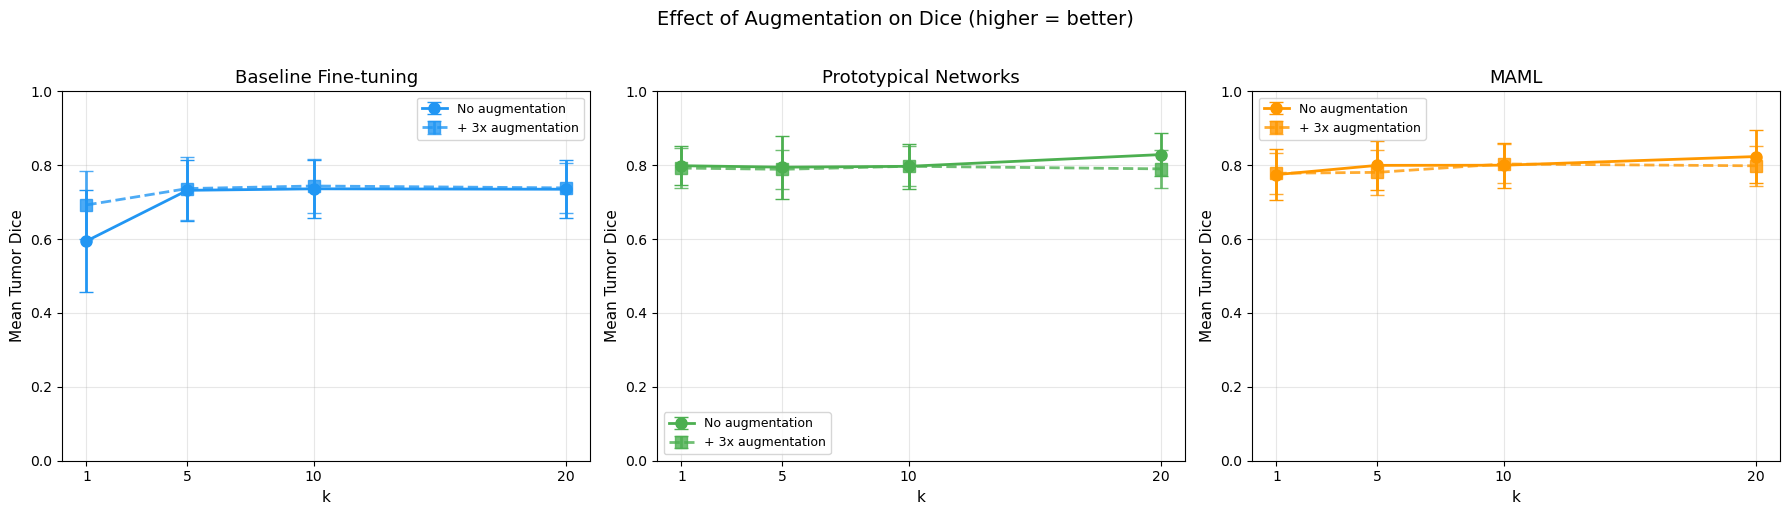

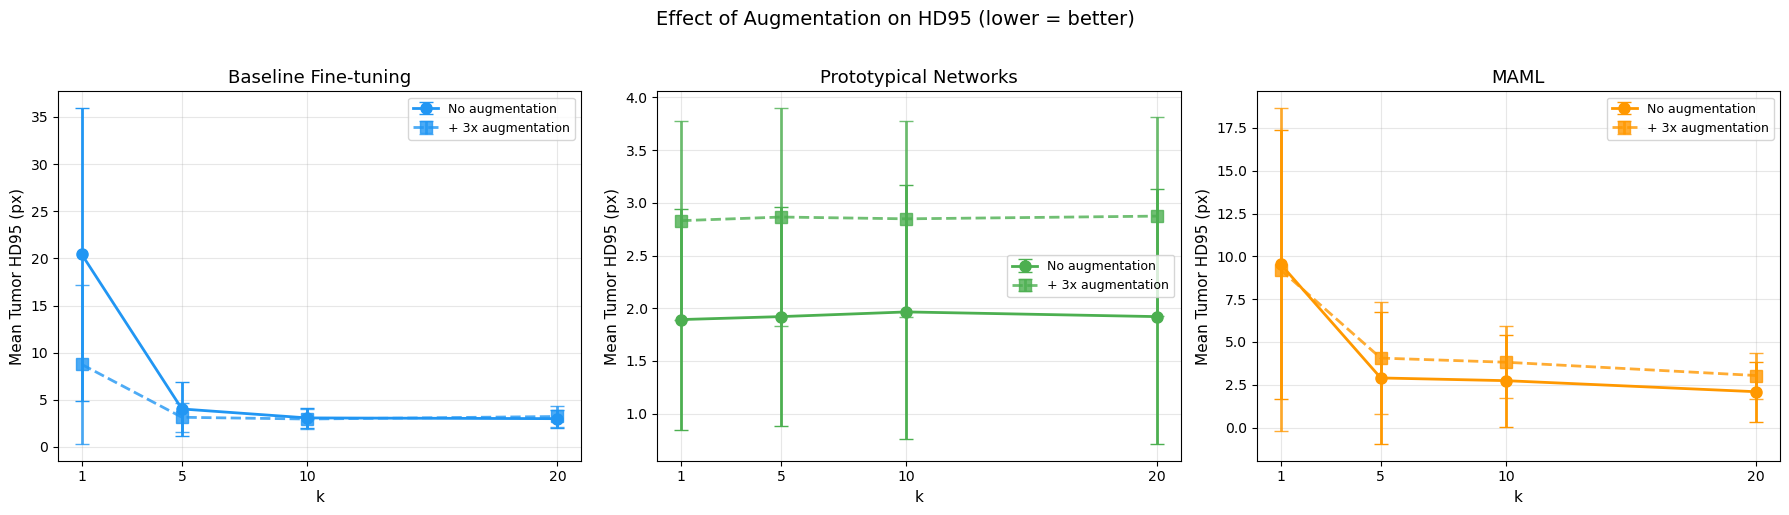

In [8]:
# CELL 8: Comparison Charts — Each Method: Original vs Augmented (Dice + HD95)
k_values = Config.K_SHOT_VALUES

methods = [
    ('Baseline Fine-tuning', baseline_orig, baseline_aug_results, '#2196F3'),
    ('Prototypical Networks', proto_orig, proto_aug_results, '#4CAF50'),
    ('MAML', maml_orig, maml_aug_results, '#FF9800'),
]

# ── Dice comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, orig, aug, color) in zip(axes, methods):
    if orig is None or not aug:
        ax.set_title(f'{name}\n(results not available)')
        ax.axis('off')
        continue

    orig_means = [orig[str(k)]['mean'] for k in k_values]
    orig_stds = [orig[str(k)]['std'] for k in k_values]
    ax.errorbar(k_values, orig_means, yerr=orig_stds, marker='o', capsize=5,
                linewidth=2, markersize=8, color=color, label='No augmentation',
                linestyle='-')

    aug_means = [aug[k]['mean'] for k in k_values]
    aug_stds = [aug[k]['std'] for k in k_values]
    ax.errorbar(k_values, aug_means, yerr=aug_stds, marker='s', capsize=5,
                linewidth=2, markersize=8, color=color, label=f'+ {AUGMENT_FACTOR}x augmentation',
                linestyle='--', alpha=0.8)

    ax.set_xlabel('k', fontsize=11)
    ax.set_ylabel('Mean Tumor Dice', fontsize=11)
    ax.set_title(name, fontsize=13)
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)

plt.suptitle('Effect of Augmentation on Dice (higher = better)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'augmentation_ablation_dice.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# ── HD95 comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, orig, aug, color) in zip(axes, methods):
    if orig is None or not aug:
        ax.set_title(f'{name}\n(results not available)')
        ax.axis('off')
        continue

    has_hd95_orig = 'hd95_mean' in orig[str(k_values[0])]
    has_hd95_aug = 'hd95_mean' in aug[k_values[0]]

    if not has_hd95_orig or not has_hd95_aug:
        ax.set_title(f'{name}\n(HD95 not available)')
        ax.axis('off')
        continue

    orig_means = [orig[str(k)]['hd95_mean'] for k in k_values]
    orig_stds = [orig[str(k)]['hd95_std'] for k in k_values]
    ax.errorbar(k_values, orig_means, yerr=orig_stds, marker='o', capsize=5,
                linewidth=2, markersize=8, color=color, label='No augmentation',
                linestyle='-')

    aug_means = [aug[k]['hd95_mean'] for k in k_values]
    aug_stds = [aug[k]['hd95_std'] for k in k_values]
    ax.errorbar(k_values, aug_means, yerr=aug_stds, marker='s', capsize=5,
                linewidth=2, markersize=8, color=color, label=f'+ {AUGMENT_FACTOR}x augmentation',
                linestyle='--', alpha=0.8)

    ax.set_xlabel('k', fontsize=11)
    ax.set_ylabel('Mean Tumor HD95 (px)', fontsize=11)
    ax.set_title(name, fontsize=13)
    ax.set_xticks(k_values)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle('Effect of Augmentation on HD95 (lower = better)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(Config.RESULTS_DIR, 'augmentation_ablation_hd95.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# CELL 9: Delta Table — Dice + HD95
k_values = Config.K_SHOT_VALUES

# Dice delta
print(f"\n{'='*75}")
print("AUGMENTATION EFFECT — DICE (higher = better)")
print(f"{'='*75}")
print(f"{'Method':<25} {'k=1':<12} {'k=5':<12} {'k=10':<12} {'k=20':<12}")
print(f"{'-'*75}")

for name, orig, aug in [
    ('Baseline', baseline_orig, baseline_aug_results),
    ('Prototypical', proto_orig, proto_aug_results),
    ('MAML', maml_orig, maml_aug_results),
]:
    if orig is None or not aug:
        continue
    row = f"{name:<25}"
    for k in k_values:
        orig_mean = orig[str(k)]['mean']
        aug_mean = aug[k]['mean']
        delta = aug_mean - orig_mean
        row += f" {delta:+.4f}     "
    print(row)
print(f"{'='*75}")
print("Positive = augmentation helped")

# HD95 delta
print(f"\n{'='*75}")
print("AUGMENTATION EFFECT — HD95 (lower = better, so negative = helped)")
print(f"{'='*75}")
print(f"{'Method':<25} {'k=1':<12} {'k=5':<12} {'k=10':<12} {'k=20':<12}")
print(f"{'-'*75}")

for name, orig, aug in [
    ('Baseline', baseline_orig, baseline_aug_results),
    ('Prototypical', proto_orig, proto_aug_results),
    ('MAML', maml_orig, maml_aug_results),
]:
    if orig is None or not aug:
        continue
    if 'hd95_mean' not in orig[str(k_values[0])] or 'hd95_mean' not in aug[k_values[0]]:
        continue
    row = f"{name:<25}"
    for k in k_values:
        orig_hd = orig[str(k)]['hd95_mean']
        aug_hd = aug[k]['hd95_mean']
        delta = aug_hd - orig_hd
        row += f" {delta:+.1f}px     "
    print(row)
print(f"{'='*75}")
print("Negative = augmentation improved boundary precision")


AUGMENTATION EFFECT — DICE (higher = better)
Method                    k=1          k=5          k=10         k=20        
---------------------------------------------------------------------------
Baseline                  +0.0977      +0.0048      +0.0076      +0.0037     
Prototypical              -0.0064      -0.0058      +0.0001      -0.0387     
MAML                      +0.0037      -0.0189      +0.0034      -0.0251     
Positive = augmentation helped

AUGMENTATION EFFECT — HD95 (lower = better, so negative = helped)
Method                    k=1          k=5          k=10         k=20        
---------------------------------------------------------------------------
Baseline                  -11.7px      -0.9px      -0.1px      +0.2px     
Prototypical              +0.9px      +0.9px      +0.9px      +1.0px     
MAML                      -0.3px      +1.2px      +1.1px      +0.9px     
Negative = augmentation improved boundary precision
